# CCN 2024 Spoken Wiki attentional word recognition pilot task results

### Plotted:
Will use pre-saved human results, and look at best-matching and control architecture model 


In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



In [2]:
outfig_dest = Path('CCN_2024/figures')
outfig_dest.mkdir(parents=True, exist_ok=True)





### Import human data

In [3]:
part_summary_df = pd.read_pickle("2023_swc_attn_word_rec_prolific_good_parts_n_81.pdpkl")

# Get wanted columns 
part_summary_df = part_summary_df[['snr', 'id_subject', 'condition', 'adjusted_accuracy_mean','adjusted_confusions_mean']]

# rename for match to model and plots 
part_summary_df.columns = ['snr', 'id_subject', 'background_condition', 'accuracy', 'confusions']
part_summary_df['group'] = 'Human'

In [4]:
## Raname conditions to match plots
part_summary_df.background_condition.replace({"clean": 'no distractor', 'stationary': 'noise'}, inplace=True)

## Load Model Results 

In [5]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [6]:
manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_all_condition_ground_truth_manifest.pdpkl")


In [7]:
model_names = ["word_task_half_co_loc_v07", 'word_task_v08_control_no_attn']
             
model_name_dict = {"word_task_half_co_loc_v07": "Feature-based\nattention model",
                   'word_task_v08_control_no_attn': 'Baseline CNN'
                  }

all_model_results = []
all_model_f0_results = []

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                    "babble":"background_cv08talkerbabble",
                    "noise": "background_issnstationary",
                    "modulated": "background_issnfestenplomp",
                    "audioset": "background_audioset",
                    "natural scene": "background_ieeeaaspcasa",
                    "no distractor": "SILENCE"}
str_to_cond = {v:k for k,v in test_condition_dict.items()}

# update gt manifests to match readable format 
manifests["background_condition"] = manifests.condition.replace(str_to_cond, )

for model_name in model_names:
    if "v0" in model_name:
        output_paths = list(Path(f'swc_mono_eval/{model_name}').glob('*.csv'))
        print(len(output_paths))

    elif model_name == "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor":
        output_paths = list(Path(f'../Auditory-Attention/swc_mono_eval/{model_name}').glob('*.csv'))
        print(len(output_paths))
    results_dfs = []


    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        #parts of name 
        parts = path.stem.split(path.parent.name)[-1].split('_')       
        if "background" in path.stem:
            df['background_condition'] = str_to_cond['_'.join(parts[1:3])]
        else:
            df['background_condition'] = parts[1]
        if 'SILENCE' in path.stem:
            df['background_condition'] = 'no distractor'
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        results_dfs.append(df)
    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name]
    model_results['group'] = model_str
    ## Load in model vocab 
    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_str else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


    # Add 1-talker condition metadata to model results
    model_results = pd.merge(model_results,
            manifests[["background_condition", "snr", "word", "word_int", 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcript', 'distractor_transcript']],
                        left_on=['background_condition', 'snr', "true_word"], right_on=["background_condition", "snr",  "word"], how='left')


    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    distractor_words = model_results.distractor_word.values
    target_transcripts = model_results.target_transcript.values
    distractor_transcripts = model_results.distractor_transcript.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                                if not isinstance(distractor_transcript, float) else np.nan
                                for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    
    all_model_results.append(model_results)

    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'clean'])]
    model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
    model_f0_df.loc[model_f0_df.background_condition == 'clean', 'gender_cond'] = 'clean'
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)

41


/tmp/ipykernel_901/4211017731.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
/tmp/ipykernel_901/4211017731.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
/tmp/ipykernel_901/4211017731.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

41


/tmp/ipykernel_901/4211017731.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
/tmp/ipykernel_901/4211017731.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
/tmp/ipykernel_901/4211017731.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [8]:
all_model_results.columns

Index(['pred_word_int', 'true_word_int', 'accuracy', 'model',
       'background_condition', 'snr', 'group', 'pred_word', 'true_word',
       'word', 'word_int', 'target_gender', 'target_f0', 'distractor_f0',
       'distractor_gender', 'distractor_word', 'target_transcript',
       'distractor_transcript', 'confusions', 'adjusted_accuracy',
       'adjusted_confusions'],
      dtype='object')

In [9]:
### get just the wanted columns 

all_model_results = all_model_results[['snr','group','background_condition', 'accuracy', 'confusions']]


In [10]:


# model_summary_df['group'] = model_summary_df['model']
# model_results['group'] = 'model'

# combine model and participant results ignore missing columns
combined_results = pd.concat([part_summary_df, all_model_results], axis=0, ignore_index=True)

In [11]:
combined_results.loc[combined_results.snr == np.inf, 'snr'] = 6
combined_results.loc[combined_results.snr == 'inf', 'snr'] = 6
combined_results.snr = combined_results.snr.astype('int')

In [12]:
combined_results.group.unique()

array(['Human', 'Feature-based\nattention model', 'Baseline CNN'],
      dtype=object)

## Standard analysis 

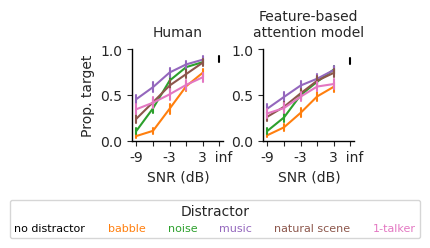

In [194]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]

# sns.set_context('notebook')
sns.set_style('ticks')
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset', 'modulated'])]
to_plot = to_plot[to_plot.group.isin(['Human', 'Feature-based\nattention model'])]

hue_order = ['no distractor', 'babble',  'noise', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['no distractor'] = 'k'
hue_order = ['no distractor', 'babble',  'noise', 'music', 'natural scene', "1-talker"]


# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', 
                 hue='background_condition', hue_order=hue_order,
                 col='group', col_wrap=3, 
                #  col_order = ['Human', 'Feature-based\nattention model', 'Baseline CNN'],
                facet_kws={'sharey':False},
                # style='group',  style_order =  ],#'Baseline CNN'],
                kind='line', palette=palette, height=2, aspect=1, 
                err_style='bars', errorbar=('se', 2))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# make markers open with white face and color matching palette 
# for ax in g.axes.flat:
#     for line in ax.get_lines():
#         line.set_markerfacecolor('w')
#         line.set_markeredgecolor(line.get_color())
#         line.set_marker('o')
#         line.set_markersize(3)
#         line.set_linewidth(1.5)
#         line.set_linestyle('-')
#         line.set_alpha(1)

fontsize = 10 

# set labels 
g.set_axis_labels("SNR (dB)", "Prop. target", fontsize=fontsize)
g.set_titles("{col_name}", size=fontsize, y=1.05)

x_tick_locs = to_plot.snr.unique()
# x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
x_tick_labels = ['-9', '', '-3', '', '3', '  inf']
y_ticks = np.linspace(0,1,3).round(1)
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels,fontsize=fontsize) 
    ax.set_yticks(ticks=y_ticks) # set new labels
    ax.set_yticklabels(labels= y_ticks, fontsize=fontsize)
    ax.set_ylim(0,1)

# plt.title(f"Word recognition", fontsize=fontsize)
# g.legend.set_title('distractor')
g.legend.remove()
# plt.tight_layout()


ratio = 1.0
# increase axis thickness and set to square aspect
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

pos = g.axes[1].get_position()
pos.x0 -= 0.14
g.axes[1].set_position(pos)


handles, labels = g.axes.flat[0].get_legend_handles_labels()

legend = g.fig.legend([g.axes.flat[0].plot([],[])[0] for _ in   labels], labels,
                fancybox=True,
                handlelength=0, handleheight=0, handletextpad=0,
                title='Distractor', 
                title_fontsize=fontsize, fontsize=fontsize-2, ncol=6, loc='center',
                bbox_to_anchor=(0.25, -0.1))
for text in legend.get_texts():
    text.set_color(palette[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)

# plt.tight_layout()
plt.savefig(outfig_dest/'attn_word_rec_new_aspect.pdf', transparent=True, bbox_inches='tight')
# 


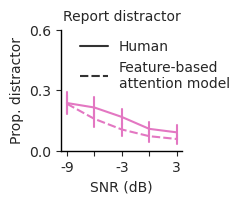

In [186]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]

# sns.set_context('notebook')
sns.set_style('ticks')
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset', 'modulated'])]
to_plot = to_plot[to_plot.snr < 6]
hue_order = ['no distractor', 'babble',  'noise', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['no distractor'] = 'k'
hue_order = ["1-talker"]


# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='confusions', 
                 hue='background_condition', hue_order=hue_order,
                #  col='group', col_wrap=3, 
                #  col_order =
                # facet_kws={'sharey':False},
                style='group', style_order =  ['Human', 'Feature-based\nattention model', ],#'Baseline CNN'],
                kind='line', palette=palette, height=2, aspect=1.2, 
                err_style='bars', errorbar=('se', 2))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# make markers open with white face and color matching palette 
# for ax in g.axes.flat:
    # for line in ax.get_lines():
    #     line.set_markerfacecolor('w')
    #     line.set_markeredgecolor(line.get_color())
    #     line.set_marker('o')
    #     line.set_markersize(3)
    #     # line.set_linewidth(1.5)
    #     # line.set_linestyle('-')
    #     line.set_alpha(1)



fontsize = 10 

# set labels 
g.set_axis_labels("SNR (dB)", "Prop. distractor", fontsize=fontsize)
# g.set_titles("{col_name}", size=fontsize, y=1.05)

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels = ['-9', '', '-3', '', '3']

# x_tick_labels[-1] = 'inf'

y_ticks = np.linspace(0,0.6,3).round(1)
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels,fontsize=fontsize) 
    ax.set_yticks(ticks=y_ticks) # set new labels
    ax.set_yticklabels(labels= y_ticks, fontsize=fontsize)

# plt.ylim(0,.6)
plt.title(f"Report distractor", fontsize=fontsize, y=1.01)
# g.legend.set_title('distractor')
g.legend.remove()
# plt.tight_layout()


ratio = 1.0

# increase axis thickness and set to square aspect
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

# increase spacing between columns 
# plt.subplots_adjust(wspace=0.4)

# only keep line style in legend, not colors

# Remove color from legend
for ax in g.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    # handles = [h[0] for h in handles]
    ax.legend(handles[3:], labels[3:], frameon=False, loc='upper right',  bbox_to_anchor=(1.5, 1.025))





# plt.tight_layout()
# plt.savefig(outfig_dest/'attn_confs_small.pdf', transparent=True, bbox_inches='tight')
# 


# Make plots combining two above into one

In [15]:
labels

['background_condition',
 '1-talker',
 'group',
 'Human',
 'Feature-based\nattention model']

### Scatter plot of human vs model performance

In [16]:
part_summary_df.columns

Index(['snr', 'id_subject', 'background_condition', 'accuracy', 'confusions',
       'group'],
      dtype='object')

In [17]:
## Summarize participant data for aggregate plotting

part_goruped = part_summary_df.groupby(['snr', 'background_condition']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem', 'count']}).reset_index()
part_goruped.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']

part_goruped['group'] = f"Human\n(N={part_goruped.N.unique().max()})"
# part_goruped

In [18]:
## Summarize modelicipant data for aggregate plotting

model_goruped = all_model_results.groupby(['snr', 'group', 'background_condition']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem', 'count']}).reset_index()
model_goruped.columns = ['snr', 'group', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']

# model_goruped

# all_model_results

In [19]:
scatter_df = pd.concat([part_goruped, model_goruped], axis=0, ignore_index=True)


In [20]:
from scipy import stats


In [24]:
## Compute noise corrected accuracy and confusions between human and model data

# First compute 10,000 split half reliabilities for human data and model data separately    
# Then compute spearman brown correction using averaged reliability  

from tqdm import tqdm

np.random.seed(0)


# split half reliability
def split_half_reliability(data, n_splits=10000):
    reliabilities = np.zeros((n_splits,2))
    for i in tqdm(range(n_splits)):
        split1 = data.sample(frac=0.5)
        split2 = data.drop(split1.index)
        # agg accuracy and confusions 
        split1 = split1.groupby(['snr', 'background_condition']).agg({'accuracy':'mean', 'confusions':'mean'}).reset_index()
        split2 = split2.groupby(['snr', 'background_condition']).agg({'accuracy':'mean', 'confusions':'mean'}).reset_index()
        # corr acc 
        r, p = stats.pearsonr(split1['accuracy'].values, split2['accuracy'].values)
        reliabilities[i,0] = r
        # corr confusions 
        split1 = split1[split1.background_condition == '1-talker']
        split2 = split2[split2.background_condition == '1-talker']
        r, p = stats.pearsonr(split1['confusions'].values, split2['confusions'].values)
        reliabilities[i,1] = r
    
    mean_r_acc, mean_r_conf = np.mean(reliabilities, axis=0)
    split_half_r_acc = (2*mean_r_acc) / (1 + mean_r_acc)
    split_half_r_conf = (2*mean_r_conf) / (1 + mean_r_conf)
    return split_half_r_acc, split_half_r_conf, reliabilities

valid_part_trials = part_summary_df[part_summary_df.background_condition != 'catch_trial']

human_rho_acc, human_rho_conf, human_reliabilities = split_half_reliability(valid_part_trials, n_splits=10000)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:31<00:00, 109.22it/s]


In [26]:
human_rho_acc, human_rho_conf

(0.9913487990996722, 0.9074399672975975)

In [ ]:


# model_results_for_comp = results[(results.snr == -3) & (results.model == 'word_task_half_co_loc_v07')]
# model_rho, model_reliabilities = split_half_reliability(model_results_for_comp, n_splits=10000)

# # means_1 = human_df.groupby('texture_label')['accuracy'].agg(['mean', 'sem'])['mean'].values

# human_perf = human_df.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
# model_perf = model_results_for_comp.groupby('texture_label')['accuracy'].agg(['mean', 'sem']).reset_index()
# r_model_human, p = stats.pearsonr(model_perf['mean'].values, human_perf['mean'].values)

# # spearman brown correction
# spearman_brown_r = r_model_human / np.sqrt(hunan_rho * model_rho)







Feature-based
attention model
Baseline CNN


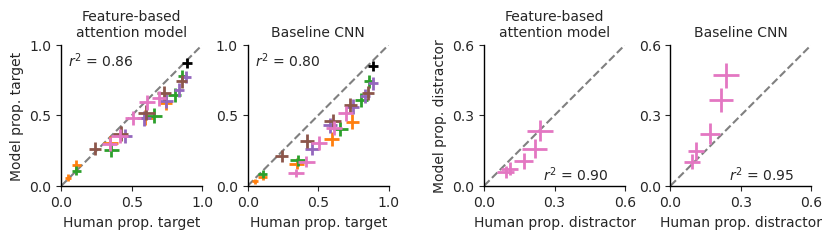

In [147]:
to_plot = scatter_df[~scatter_df.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['no distractor', 'babble',  'noise', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['no distractor'] = 'k'
hue_order = ['no distractor', 'babble',  'noise', 'music', 'natural scene', "1-talker"]


x = y = np.linspace(0,1,5)

human_str = f"Human\n(N={part_goruped.N.unique().max()})"
model_list = ['Feature-based\nattention model', 'Baseline CNN']
fontsize = 10

# model_list = ["Binaural CV no aug 50% co-located", 'Baseline CNN']
# plt_title_list = {"Binaural CV no aug 50% co-located": "Feature-based attention", 'Baseline CNN':'Baseline CNN'}
# model_list = to_plot.group.unique()[1:]

aspect = 2
fig, axs = plt.subplots(1, 2 * len(model_list), figsize=((aspect * len(model_list)) * 2.5 , aspect ))
acc_axs = axs[:2]
conf_axs = axs[2:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == human_str]
# get confusion data
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["confusions"].values
human_conf_errors = human_conf_data["conf_std_error"].values * 2 # 95% CI

for ix, model in enumerate(model_list):
    print(model)
    model_df = to_plot[to_plot.group == model]

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.background_condition == condition]
        human_means = human_data["accuracy"].values
        human_errors = human_data["acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["accuracy"].values
        model_errors = model_data["acc_std_error"].values * 2 # 95% CI

        acc_axs[ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='',
                         linestyle='', ms=3, elinewidth=line_width, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])


    # model confusions
    model_conf_data = model_df[model_df.background_condition ==  "1-talker"]
    model_conf_means = model_conf_data["confusions"].values
    model_conf_errors = model_conf_data["conf_std_error"].values * 2 # 95% CI 

    conf_axs[ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='',
                         linestyle='', ms=3, elinewidth=line_width, label= "1-talker",
                        color=palette[ "1-talker"])
    
    # Add error annotations 
    # # acc errors 
    # res = stats.spearmanr(human_df["accuracy"].values,  model_df['accuracy'].values)
    # rho = res.statistic
    # acc_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)

    r, p = stats.pearsonr(human_df["accuracy"].values,  model_df['accuracy'].values)
    # spearman_brown_r = r / np.sqrt(human_rho_acc)
    acc_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.85), fontsize=fontsize)

    # samp_rmse = np.sqrt(np.mean((human_df["accuracy"].values - model_df['accuracy'].values)**2))
    # acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

    # conf errors
    # res = stats.spearmanr(human_conf_means, model_conf_means)
    # rho = res.statistic
    # conf_axs[ix].annotate(f"$\\rho$ = {rho:.2f}", (0.3, 0.11), fontsize=fontsize)
    r, p = stats.pearsonr(human_conf_means, model_conf_means)
    # spearman_brown_r = r / np.sqrt(human_rho_conf)
    conf_axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.25, 0.025), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)

    # samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    # conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.3, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    acc_axs[ix].set_title(model, fontsize=fontsize)
    conf_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    
# set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


ticks = np.linspace(0,.6,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.6)
    ax.set_xlim(0,.6)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


    
acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)


sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

# move axs[1] to left 
pos = acc_axs[1].get_position()
pos.x0 -= 0.05
acc_axs[1].set_position(pos)

# move axs[3] to left 
pos = conf_axs[1].get_position()
pos.x0 -= 0.05
conf_axs[1].set_position(pos)


# fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.75, 0),)
# plt.tight_layout()
# 

# plt.suptitle(f"Diotic listening conditions", y=1)

# plt.savefig(outfig_dest/'scatter_plots.pdf', transparent=True, bbox_inches='tight')


In [81]:
part_summary_df.snr.unique()

array([-9, -6, -3,  0,  3,  6])

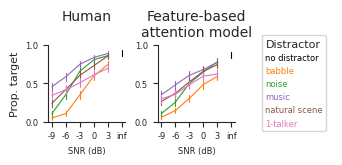

In [19]:
# Make plot with four panels, combining the previous two plots into the same figure. Put the "Prop. target" and "Prop. confusions" on the same y-axis, but with different scales.
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

## Set font to helvetica 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# set font style to 42
#  


sns.set_style('ticks')
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset', 'modulated'])]

hue_order = ['no distractor', 'babble',  'noise', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['no distractor'] = 'k'
hue_order = ['no distractor', 'babble',  'noise', 'music', 'natural scene', "1-talker"]

# needs to fit on page - dimensions are 3.375 x 1 inches
# fig, axs = plt.subplots(1, 4, figsize=(3.375, 1), sharex=True)
fig, axs = plt.subplots(1, 3, figsize=(4, 1))
fontsize = 10 
linewidth = 0.8


x_tick_locs = sorted(combined_results.snr.unique().astype('int'))
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

# Change name 'Feature-based\nattention model' to "Attention Model"
# to_plot.group.replace('Feature-based\nattention model', 'Attention Model', inplace=True)

# Plot prop target for first 3 panels. Order is [Human, Feature-based, Baseline]
for i, group in enumerate(['Human','Feature-based\nattention model']):
    to_plot_group = to_plot[to_plot.group == group]
    # for ax in axs[:3]:
    ax = axs[i]
    # make figures have square aspect ratio
    # ax.set_aspect('auto')
    ax = sns.lineplot(data=to_plot_group, x='snr', y='accuracy', 
                    hue='background_condition', hue_order=hue_order,
                    # make linesize smaller
                    linewidth=linewidth,
                    # make error bars smaller
                    err_kws={"elinewidth": linewidth, }, 
                    ax=ax, palette=palette, err_style='bars', errorbar=('se', 2))

    if group == "Human":
        ax.set_title("Human\n", fontsize=fontsize)
    else:
        ax.set_title(group, fontsize=fontsize)
    ax.set_xlabel("SNR (dB)", fontsize=fontsize-4)
    if i == 0:
        ax.set_ylabel("Prop. target", fontsize=fontsize-2)
    else:
        ax.set_ylabel("")

    ax.set_ylim(0,1)
    # if i == 0:
    ax.set_yticks(np.linspace(0,1,3).round(1))
    ax.set_yticklabels(np.linspace(0,1,3).round(1), fontsize=fontsize-4)
    # else:
        # ax.set_yticklabels([])


    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(labels=x_tick_labels, fontsize=fontsize-4)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_box_aspect(1)
    # ax.spines['top'].set_linewidth(1)
    # ax.spines['right'].set_linewidth(1)
    # ax.spines['top'].set_color('k')
    # ax.spines['right'].set_color('k')
    ax.legend().remove()

# plt.tight_layout()

# Plot prop confusions for each group on last panel
ls_dict = {'Human': '-', 'Feature-based\nattention model': '--', 'Baseline CNN': '-.'}

# put common legend for first 3 pannels on axs[3]

handles, labels = axs[1].get_legend_handles_labels()
    # handles = [h[0] for h in handles]
# remove spines for axs[3]


axs[2].axis('off')
legend = axs[2].legend([axs[2].plot([],[])[0] for _ in   labels], labels,
                fancybox=True,
                handlelength=0, handleheight=0, handletextpad=0,
                title='Distractor', 
                title_fontsize=fontsize-2, fontsize=fontsize-4, ncol=1, loc='center')
for text in legend.get_texts():
    text.set_color(palette[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)
axs[2].set_box_aspect(1)


# ax = axs[-1]

# # for  group in ['Human', 'Attention Model', 'Baseline CNN']:
# to_plot_group = to_plot[ (to_plot.background_condition == '1-talker') & (to_plot.snr < 6)]
# ax = sns.lineplot(data=to_plot_group, x='snr', y='confusions', 
#                 linewidth=linewidth,
#                 err_kws={"elinewidth": linewidth, }, 
#                 style='group', style_order= ['Human', 'Feature-based\nattention model', ],#'Baseline CNN'],
#                 ax=ax, color=palette['1-talker'], err_style='bars', errorbar=('se', 2), )#linestyle=ls_dict[group])
                
# ax.set_title("Report distractor", fontsize=fontsize)
# ax.set_xlabel("SNR (dB)", fontsize=fontsize-4)
# ax.set_ylabel("Prop. distractor", fontsize=fontsize-2)
# ax.set_ylim(0,.5)
# ticks=np.linspace(0,.5,3).round(1)
# ax.set_yticks(ticks)
# ax.set_yticklabels( ticks, fontsize=fontsize-4)

# ax.set_xticks(to_plot_group.snr.unique())
# ax.set_xticklabels(x_tick_labels[:-1], fontsize=fontsize - 4)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.set_box_aspect(1)
# ax.legend().remove()

# # Remove color from legend
# for ax in g.axes.flat:

# handles, labels = ax.get_legend_handles_labels()
# # handles = [h[0] for h in handles]
# leg = ax.legend(handles, labels, frameon=False, loc='upper right',
#                 handlelength=1.5, handleheight=0.5,# handletextpad=0,

#              fontsize=fontsize-4,  bbox_to_anchor=(1.6, 1.1))
# for item in leg.get_lines():
#     item.set_linewidth(1)
# lgnd.legendHandles[0]._legmarker.set_markersize(6)
# lgnd.legendHandles[1]._legmarker.set_markersize(6)


# plt.subplots_adjust(wspace=0.3)
# adjust spacing to move panel 4 further from panel 3
# # plt.tight_layout()

pos = axs[2].get_position()
new_pos = [pos.x0-0.03, pos.y0, pos.width, pos.height]
axs[2].set_position(new_pos)
# pos = axs[3].get_position()
# new_pos = [pos.x0+0.01, pos.y0, pos.width, pos.height]
# axs[3].set_position(new_pos)



# plt.savefig(outfig_dest/'mono_results.pdf', transparent=True, bbox_inches='tight')
# 